In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hichamachahboun/mnist-handwritten-digits/train_labels.npy
/kaggle/input/datasets/hichamachahboun/mnist-handwritten-digits/test_labels.npy
/kaggle/input/datasets/hichamachahboun/mnist-handwritten-digits/train_images.npy
/kaggle/input/datasets/hichamachahboun/mnist-handwritten-digits/readme.md
/kaggle/input/datasets/hichamachahboun/mnist-handwritten-digits/test_images.npy


In [5]:
# Dataset path
DATA_PATH = "/kaggle/input/datasets/hichamachahboun/mnist-handwritten-digits/"

# Load training data
X_train = np.load(DATA_PATH + "train_images.npy")
y_train = np.load(DATA_PATH + "train_labels.npy")

# Load testing data
X_test = np.load(DATA_PATH + "test_images.npy")
y_test = np.load(DATA_PATH + "test_labels.npy")

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


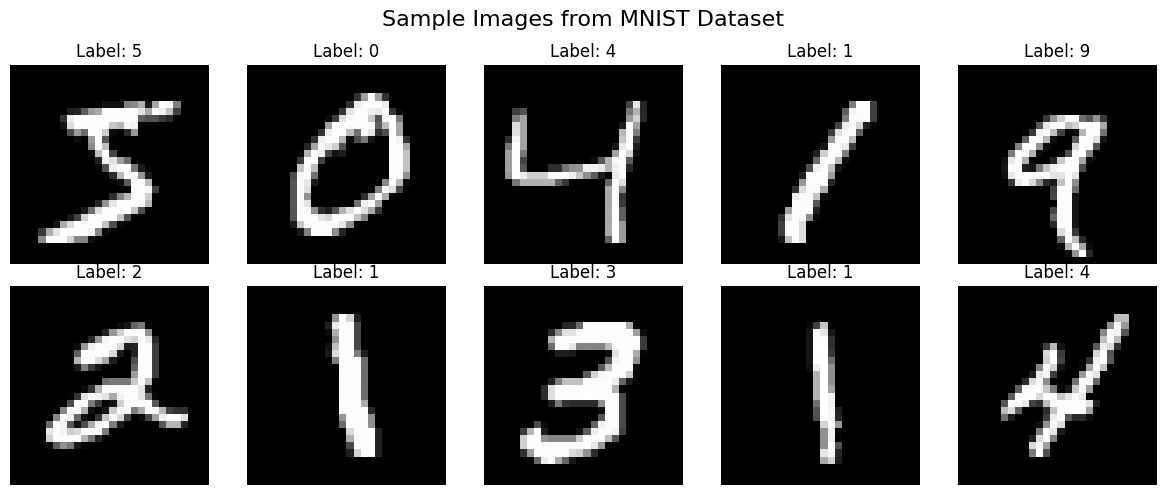

In [6]:
# Display 10 sample images from the training dataset

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample Images from MNIST Dataset", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
# Convert 28 × 28 images into 784-dimensional feature vectors

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Original image shape:", X_train.shape)
print("Flattened training data shape:", X_train_flat.shape)
print("Flattened testing data shape:", X_test_flat.shape)

Original image shape: (60000, 28, 28)
Flattened training data shape: (60000, 784)
Flattened testing data shape: (10000, 784)


In [8]:
# Normalize pixel values from 0-255 to 0-1

X_train_scaled = X_train_flat / 255.0
X_test_scaled = X_test_flat / 255.0

print("Minimum pixel value:", X_train_scaled.min())
print("Maximum pixel value:", X_train_scaled.max())
print("Scaled data shape:", X_train_scaled.shape)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Scaled data shape: (60000, 784)


In [9]:
# Apply PCA to reduce 784 dimensions to 2 dimensions

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_pca.shape[1])
print("PCA output shape:", X_pca.shape)

Original number of features: 784
Number of PCA components: 2
PCA output shape: (60000, 2)


In [10]:
# Calculate the variance captured by the two principal components

explained_variance = pca.explained_variance_ratio_

print("Variance explained by PC1:", explained_variance[0])
print("Variance explained by PC2:", explained_variance[1])
print("Total variance explained:", explained_variance.sum())

Variance explained by PC1: 0.09704664359715665
Variance explained by PC2: 0.07095924059092555
Total variance explained: 0.1680058841880822


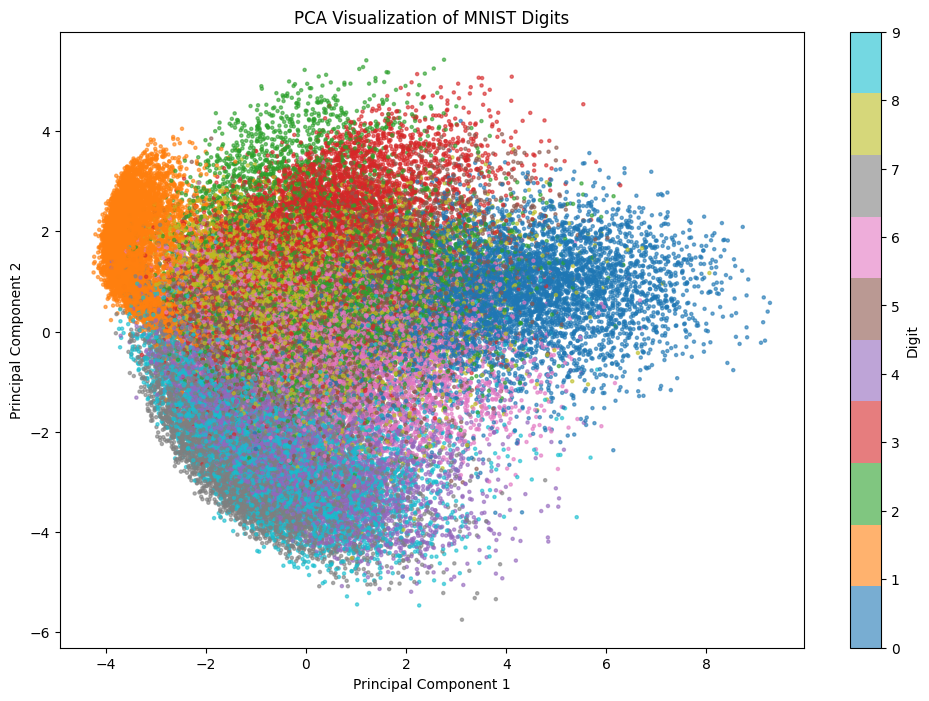

In [11]:
# Visualize the PCA-reduced data

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_train,
    cmap="tab10",
    s=5,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of MNIST Digits")

plt.colorbar(scatter, label="Digit")

plt.show()

In [12]:
# Use a subset of 10,000 samples for faster t-SNE computation
n_samples = 10000

X_tsne_input = X_train_scaled[:n_samples]
y_tsne = y_train[:n_samples]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_tsne = tsne.fit_transform(X_tsne_input)

print("t-SNE input shape:", X_tsne_input.shape)
print("t-SNE output shape:", X_tsne.shape)

t-SNE input shape: (10000, 784)
t-SNE output shape: (10000, 2)
